# Assignment5 - Kaggle competition and Unsupervised learning

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


## Exercise 1 - Kaggle classification competitio

**1.1 Explore data**

Load and inspect dimensions

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_pickle("data/a5_q1.pkl")
X_train = data["X_train"]
y_train = data["y_train"]
X_train_ohe = data["X_train_ohe"]


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train_ohe shape:", X_train_ohe.shape)

X_train shape: (95512, 29)
y_train shape: (95512,)
X_train_ohe shape: (95512, 940)


Identify data types and missingness

In [ ]:
# Look for missing values
missing_counts = X_train.isnull().sum()
print(missing_counts[missing_counts > 0])

print(X_train.describe())

children        2
country       395
agent       13081
company     90059
dtype: int64
          lead_time  arrival_date_year  arrival_date_week_number  \
count  95512.000000       95512.000000              95512.000000   
mean     103.849768        2016.157205                 27.152902   
std      106.722804           0.707470                 13.611204   
min        0.000000        2015.000000                  1.000000   
25%       18.000000        2016.000000                 16.000000   
50%       69.000000        2016.000000                 27.000000   
75%      160.000000        2017.000000                 38.000000   
max      709.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               95512.000000             95512.000000   
mean                   15.823038                 0.928491   
std                     8.786777                 0.999940   
min                     1.000000                 0.000000 

Visual relationships analysis

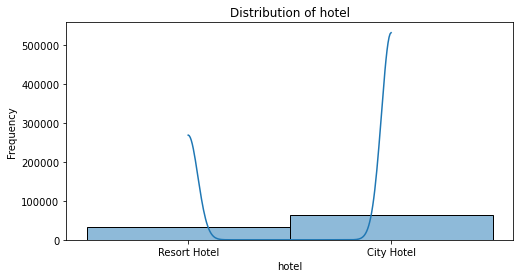

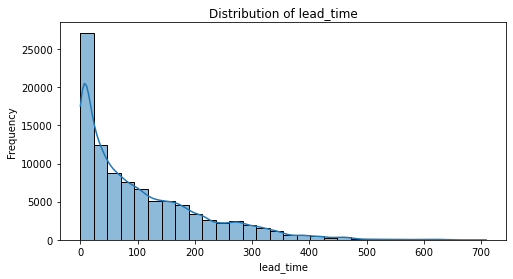

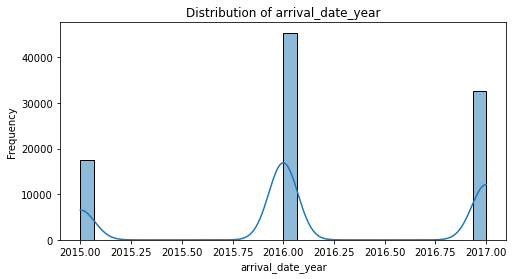

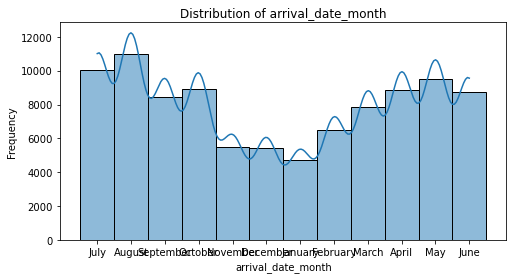

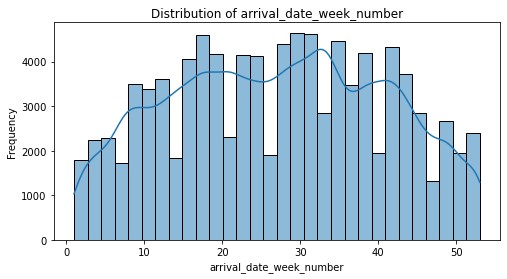

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = X_train.columns[:5]
for col in top_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**1.2 Preprocess data**

After checking the data in the 1.1, I found some problem in this data.

1. Missing values(Imputation)
    - Company: This feature has an extremely high missing rate, 90059 missing out of 95512. I will either drop this column or convert it into a binary indicator.
    - Agent: Missing values likely represenent direct bookings without an agent. I will impute these with a constant value of 0.
    - Children: There are 2 missing values. Since the median and 75th percentile are both 0, I will fill these with 0.
    - Country: There are 395 missing values. These will be filled with the mode unknown or the most frequet country.

2. Treatment of erroneous data & outliers
    - The adr feature shows a minimum value of -6.38. Since a negative price is impossible, these value will chage to 0.
    - Because features like adr, lead_time, and adults have high variance and different units, I applied StandardScaler. This ensures that distance-based models (like KNN or SVM) are not biased by the scale of the input features.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_test_original = data['X_test']
X_test_ohe_raw = pd.get_dummies(X_test_original)

# Reindex X_test_ohe_raw to match the columns of X_train_ohe
X_test_ohe = X_test_ohe_raw.reindex(columns=X_train_ohe.columns, fill_value=0)

# 1. Handle Missing Values (Imputation)
# Based on describe(), children, country, agent, and company have NaNs.
X_train_clean = X_train_ohe.fillna(0)
X_test_clean = X_test_ohe.fillna(0)

# 2. Error Correction
X_train_clean.loc[X_train_clean['adr'] < 0, 'adr'] = 0

#3. Scaling
num_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults']
scaler = StandardScaler()
X_train_clean[num_cols] = scaler.fit_transform(X_train_clean[num_cols])
X_test_clean[num_cols] = scaler.transform(X_test_clean[num_cols])

# 4. Local Validation Split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_clean, y_train, test_size=0.2, random_state=42, stratify=y_train)